# Practica 2


In [1]:
import os, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.filters import threshold_multiotsu
import warnings

random.seed(42)

LOCAL_DATASET = True
if LOCAL_DATASET:
    path = "../../../../../Downloads/archive"  # ! mismo path que en practica_2.ipynb
else:
    import kagglehub
    path = kagglehub.dataset_download("emmarex/plantdisease")

DATA_DIR = os.path.join(path, "PlantVillage")
print("DATA_DIR:", DATA_DIR)

DATA_DIR: ../../../../../Downloads/archive\PlantVillage


In [2]:
def get_class_dirs(data_dir):
    return sorted(d for d in os.listdir(data_dir)
                  if os.path.isdir(os.path.join(data_dir, d))
                  and d.lower() != "plantvillage")

def imagenes_de_clase(clase, data_dir=DATA_DIR, n=3, seed=42):
    """Devuelve n rutas de imagen (aleatorias pero reproducibles) de una clase."""
    random.seed(seed)
    cdir = os.path.join(data_dir, clase)
    exts = ('.png', '.jpg', '.jpeg', '.bmp')
    imgs = [f for f in os.listdir(cdir) if f.lower().endswith(exts)]
    return [os.path.join(cdir, f) for f in random.sample(imgs, min(n, len(imgs)))]

def muestra_todas_clases(data_dir=DATA_DIR, n_por_clase=1, seed=42):
    """Devuelve [(ruta, clase), ...] con n_por_clase imágenes de CADA clase."""
    random.seed(seed)
    exts = ('.png', '.jpg', '.jpeg', '.bmp')
    muestra = []
    for c in get_class_dirs(data_dir):
        cdir = os.path.join(data_dir, c)
        imgs = [f for f in os.listdir(cdir) if f.lower().endswith(exts)]
        for f in random.sample(imgs, min(n_por_clase, len(imgs))):
            muestra.append((os.path.join(cdir, f), c))
    return muestra

clases = get_class_dirs(DATA_DIR)
print(f'{len(clases)} clases disponibles:')
for i, c in enumerate(clases):
    print(f'  [{i}] {c}')

15 clases disponibles:
  [0] Pepper__bell___Bacterial_spot
  [1] Pepper__bell___healthy
  [2] Potato___Early_blight
  [3] Potato___Late_blight
  [4] Potato___healthy
  [5] Tomato_Bacterial_spot
  [6] Tomato_Early_blight
  [7] Tomato_Late_blight
  [8] Tomato_Leaf_Mold
  [9] Tomato_Septoria_leaf_spot
  [10] Tomato_Spider_mites_Two_spotted_spider_mite
  [11] Tomato__Target_Spot
  [12] Tomato__Tomato_YellowLeaf__Curl_Virus
  [13] Tomato__Tomato_mosaic_virus
  [14] Tomato_healthy


In [3]:
def to_grayscale(bgr):
    """Escala de grises por luminosidad (ITU-R BT.601)."""
    b, g, r = bgr[:, :, 0], bgr[:, :, 1], bgr[:, :, 2]
    return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

def aplicar_filtro(gray, filtro, ksize):
    """Suavizado: 'gaussian' o 'median'."""
    if filtro == 'gaussian':
        return cv2.GaussianBlur(gray, (ksize, ksize), 0)
    elif filtro == 'median':
        return cv2.medianBlur(gray, ksize)
    raise ValueError("filtro debe ser 'gaussian' o 'median'")

def cdf_histograma(gray):
    """Histograma acumulado (CDF) normalizado al rango [0, 255]."""
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    cdf = np.cumsum(hist)
    return (cdf - cdf.min()) / (cdf.max() - cdf.min()) * 255

def ecualizar_histograma(gray):
    """Mejora de contraste: usa la CDF como función de transferencia (LUT)."""
    lut = cdf_histograma(gray).astype(np.uint8)
    return lut[gray]

def orient_leaf_as_foreground(mask):
    """Deja la hoja en blanco (asume que el fondo domina el borde de la imagen)."""
    border = np.concatenate([mask[0, :], mask[-1, :], mask[:, 0], mask[:, -1]])
    return cv2.bitwise_not(mask) if border.mean() > 100 else mask

def segmentar(gray, metodo, global_t=127):
    """'global' | 'otsu'"""
    if metodo == 'global':
        _, m = cv2.threshold(gray, global_t, 255, cv2.THRESH_BINARY)
        return orient_leaf_as_foreground(m)
    elif metodo == 'otsu':
        _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return orient_leaf_as_foreground(m)
    raise ValueError(f"método desconocido: {metodo}")

def aplicar_morfologia(mask, operacion, ksize):
    """'erosion' | 'dilatacion' | 'apertura' | 'cierre'"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    if operacion == 'erosion':
        return cv2.erode(mask, kernel, iterations=1)
    elif operacion == 'dilatacion':
        return cv2.dilate(mask, kernel, iterations=1)
    elif operacion == 'apertura':
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    elif operacion == 'cierre':
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    raise ValueError(f"operación desconocida: {operacion}")


def construir_pipeline(filtro='gaussian', ksize_filtro=5, contraste=False,
                        metodo_seg='otsu', global_t=127,
                        operaciones_morf=()):
    """Arma la lista de pasos (nombre, función) siguiendo el flujo fijo:
    Gris -> [Contraste] -> Filtro -> Segmentación -> Operaciones morfológicas (encadenadas).

    contraste: si es True, inserta la mejora de contraste por histograma acumulado (CDF)
        justo después de pasar a gris y antes del filtro de suavizado.
    operaciones_morf: lista de (operacion, ksize) aplicadas en ese orden, ej.
        [('dilatacion', 10), ('erosion', 3)]
    """
    pasos = [('Gris', to_grayscale)]
    if contraste:
        pasos.append(('Contraste (CDF)', ecualizar_histograma))
    pasos.append((f'Filtro ({filtro}, k={ksize_filtro})', lambda img: aplicar_filtro(img, filtro, ksize_filtro)))
    pasos.append((f'Segmentacion ({metodo_seg})', lambda img: segmentar(img, metodo_seg, global_t)))
    for op, ksize in operaciones_morf:
        pasos.append((f'{op.capitalize()} (k={ksize})',
                      lambda img, op=op, ksize=ksize: aplicar_morfologia(img, op, ksize)))
    return pasos

def ejecutar_pipeline(bgr, pasos):
    """Aplica cada paso en orden. Devuelve [('Original', bgr_rgb), (nombre1, img1), ...]."""
    resultados = [('Original', cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))]
    actual = bgr
    for nombre, fn in pasos:
        actual = fn(actual)
        resultados.append((nombre, actual))
    return resultados

print('Funciones del pipeline listas.')

Funciones del pipeline listas.


## 3.1, 3.2,  3.3

Aqui se testean los diferente pipelines posibles, esta comentado ya que mostra la figura demora un tanto.

In [4]:
# --- PIPELINES A COMPARAR: mismo pipeline, con y sin mejora de contraste ---
CARPETA_SALIDA = 'comparaciones_pipelines'
os.makedirs(CARPETA_SALIDA, exist_ok=True)

PIPELINES = {
    # 'P1': construir_pipeline(
    #     filtro='gaussian', ksize_filtro=5, contraste=False,
    #     metodo_seg='otsu',
    #     operaciones_morf=[('dilatacion', 11), ('erosion', 3)],
    # ),
    # 'P2': construir_pipeline(
    #     filtro='gaussian', ksize_filtro=5, contraste=True,
    #     metodo_seg='otsu',
    #     operaciones_morf=[('dilatacion', 11), ('erosion', 3)],
    # ),
    # 'P3': construir_pipeline(
    #         filtro='gaussian', ksize_filtro=5, contraste=True,
    #         metodo_seg='otsu',
    #         operaciones_morf=[('dilatacion', 3), ('erosion', 3)],
    #     ),
}

muestra_cmp = muestra_todas_clases(n_por_clase=2)

CARPETA_SALIDA = 'comparaciones_pipelines'
os.makedirs(CARPETA_SALIDA, exist_ok=True)

muestra_cmp = muestra_todas_clases(n_por_clase=2)

for nombre_pipeline, pasos in PIPELINES.items():
    titulo = f'{nombre_pipeline}: ' + ' -> '.join(nombre for nombre, _ in pasos)

    fig, axes = plt.subplots(len(muestra_cmp), len(pasos) + 1,
                             figsize=(3.2*(len(pasos)+1), 3.2*len(muestra_cmp)))
    if len(muestra_cmp) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(titulo, fontsize=12, y=1.0)
    for i, (ruta, clase) in enumerate(muestra_cmp):
        bgr = cv2.imread(ruta)
        resultados = ejecutar_pipeline(bgr, pasos)
        for ax, (paso_nombre, img) in zip(axes[i], resultados):
            cmap = None if img.ndim == 3 else 'gray'
            ax.imshow(img, cmap=cmap); ax.axis('off')
            if i == 0: ax.set_title(paso_nombre, fontsize=9)
        axes[i, 0].set_ylabel(clase, fontsize=6)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    ruta_salida = os.path.join(CARPETA_SALIDA, f'{nombre_pipeline}.png')
    fig.savefig(ruta_salida, dpi=150, bbox_inches='tight')
    print(f'Guardado: {ruta_salida}')

    # plt.show()
    plt.close(fig)

In [5]:
# --- PIPELINE FINAL (P3) -- punto de partida para 3.4 y 3.5 ---
PIPELINE_FINAL = construir_pipeline(
    filtro='gaussian', ksize_filtro=5, contraste=True,
    metodo_seg='otsu',
    operaciones_morf=[('dilatacion', 10), ('erosion', 3)],
)

def procesar_hasta_operaciones_morfologicas(ruta):
    """Corre PIPELINE_FINAL sobre una imagen.
    Devuelve (bgr_original, mascara_binaria) listos para bordes/esquinas."""
    bgr = cv2.imread(ruta)
    resultados = ejecutar_pipeline(bgr, PIPELINE_FINAL)
    mascara = resultados[-1][1]
    return bgr, mascara

print('Pipeline final (P3):', ' -> '.join(nombre for nombre, _ in PIPELINE_FINAL))

muestra = muestra_todas_clases(n_por_clase=2)
muestra_procesada = []
for ruta, clase in muestra:
    bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
    muestra_procesada.append((ruta, clase, bgr, mascara))




Pipeline final (P3): Gris -> Contraste (CDF) -> Filtro (gaussian, k=5) -> Segmentacion (otsu) -> Dilatacion (k=10) -> Erosion (k=3)


## Fin 3.3


!Importante

- **`muestra_procesada`** tiene el resultado de aplicar el pipeline hasta operaciones morfologicas: Estes es una lista de `(ruta, clase, bgr, mascara)`.


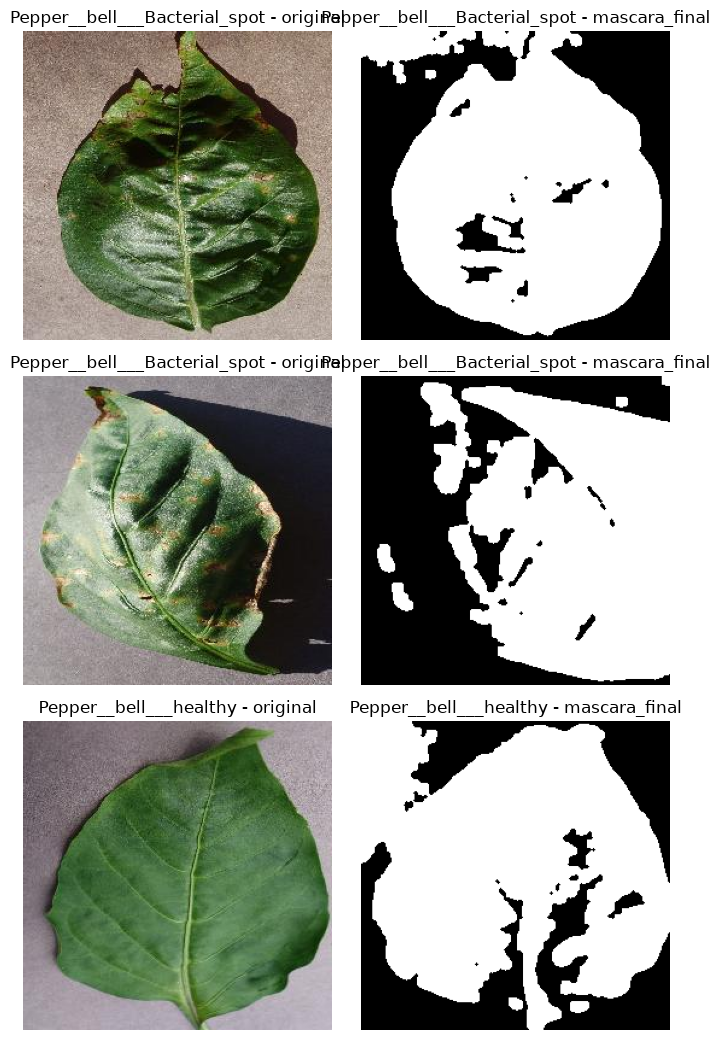

In [6]:
# Ejemplo de recorrido para observar muestra_procesada
n_mostrar = 3
fig, axes = plt.subplots(n_mostrar, 2, figsize=(7, 3.5 * n_mostrar))
for i, (ruta, clase, bgr, mascara) in enumerate(muestra_procesada[:n_mostrar]):
    axes[i, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); axes[i, 0].set_title(f'{clase} - original'); axes[i, 0].axis('off')
    axes[i, 1].imshow(mascara, cmap='gray'); axes[i, 1].set_title(f'{clase} - mascara_final'); axes[i, 1].axis('off')
plt.tight_layout(); plt.show()